# Baseline Determination

Determination of the east–west baseline $b_{\mathrm{ew}}$ using three independent methods: FFT in the $x$-coordinate, phase slope, and lag-spectrum delay.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, projected_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    nls_baseline_single_channel, nls_baseline_broadband,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, characterize_sunspot_flux,
    # plotting
    PRIMARY_COLOR, SECONDARY_COLOR, TERTIARY_COLOR, QUATERNARY_COLOR,
    NEUTRAL_COLOR, COMPONENT_COLORS,
    SCATTER_S_FINE, SCATTER_S_STANDARD,
    LW_FINE, LW_GUIDE, LW_STANDARD, LW_MODEL,
    MARKER_MS_SMALL,
    TEXTWIDTH_IN, TICK_SIZE,
)
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 17–43 captures
  Chip 1: window range 17–27 captures
  Chip 2: window range 17–31 captures
Bad channels:       [0, 256, 512, 768]


# Part IV: Baseline Determination

We determine both baseline components $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$ using four independent methods, applied per chip.

## 4.1 Method 1: FFT in the x-coordinate

The visibility phase is $\phi = 2\pi(b_{\mathrm{ew}}/\lambda)\,x$ where $x = \cos\delta\,\sin h$. In this coordinate the fringe is a pure sinusoid with spatial frequency $f_x = b_{\mathrm{ew}}/\lambda$, so taking the FFT of the visibility in uniformly-sampled $x$ and finding the peak directly gives the baseline:

$$\boxed{b_{\mathrm{ew}} = |f_{x,\mathrm{peak}}| \times \frac{c}{\nu}.}$$

> **Limitation:** The $x$-coordinate linearisation absorbs the $\cos h$ term from $b_{\mathrm{ns}}$ — this method **only measures $b_{\mathrm{ew}}$** and returns $b_{\mathrm{ns}} = 0$ with infinite uncertainty. Methods 2–4 below recover both components.

In [4]:
# --- Method 1: FFT baseline (per chip + pooled, broadband) ---
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)

fft_results = []
fft_per_channel = []

for ci, sl in enumerate(chip_slices):
    ha_chip = ha_rad_arr[sl]
    corr_chip = corr_dc[sl]
    dec_chip = np.deg2rad(np.nanmean(sun_dec[sl]))

    res, per_ch = fft_baseline_broadband(
        ha_chip, corr_chip, dec_chip, F_SKY_HZ,
        bad_channels=BAD_CHANNELS, band_hz=band_hz,
    )
    fft_results.append(res)
    fft_per_channel.append(per_ch)

    if res is not None:
        print(f"  Chip {ci}: B_EW = {res.b_ew_m:.4f} +/- {res.b_ew_err_m:.4f} m  "
              f"({res.n_points} ch, SNR={res.metadata.get('median_snr', 0):.1f})")

# Pooled: all chips combined
fft_pooled, fft_pooled_pc = fft_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_mean, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
fft_results.append(fft_pooled)
if fft_pooled is not None:
    print(f"  Pooled: B_EW = {fft_pooled.b_ew_m:.4f} +/- {fft_pooled.b_ew_err_m:.4f} m  "
          f"({fft_pooled.n_points} ch, SNR={fft_pooled.metadata.get('median_snr', 0):.1f})")

  Chip 0: B_EW = 15.6414 +/- 0.0050 m  (285 ch, SNR=140.6)
  Chip 1: B_EW = 15.2106 +/- 0.0073 m  (285 ch, SNR=45.5)
  Chip 2: B_EW = 14.9470 +/- 0.0015 m  (285 ch, SNR=150.2)
  Pooled: B_EW = 15.5439 +/- 0.0026 m  (285 ch, SNR=117.1)


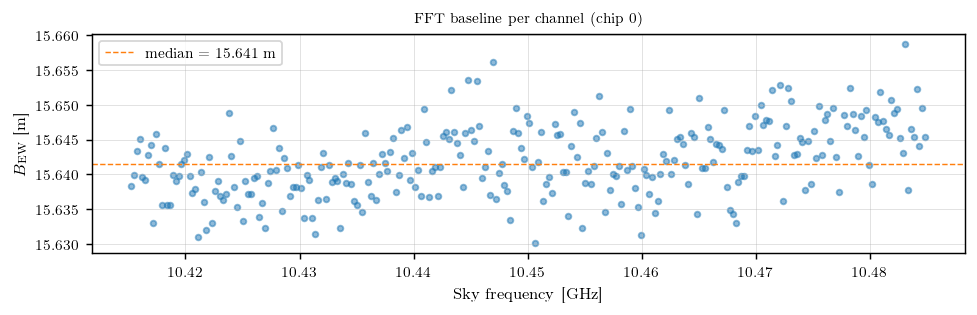

In [5]:
# --- FFT baseline: per-channel distribution for the longest chip ---
best_chip = max(range(N_chips), key=lambda i: chip_slices[i].stop - chip_slices[i].start)
pc = fft_per_channel[best_chip]
valid_ch = np.isfinite(pc["b_ew_m"])

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.5))
ax.scatter(F_SKY_GHZ[valid_ch], pc["b_ew_m"][valid_ch], s=SCATTER_S_FINE,
           color=PRIMARY_COLOR, alpha=0.5)
if fft_results[best_chip] is not None:
    ax.axhline(fft_results[best_chip].b_ew_m, color=SECONDARY_COLOR, lw=LW_GUIDE,
               ls="--", label=f"median = {fft_results[best_chip].b_ew_m:.3f} m")
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel(r"$B_{\rm EW}$ [m]")
ax.set_title(f"FFT baseline per channel (chip {best_chip})", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

## 4.2 Method 2: Phase slope against sin(h) and cos(h)

The unwrapped visibility phase at frequency $\nu$ is

$$\phi(h) = -\frac{2\pi\nu}{c}\bigl[b_{\mathrm{ew}}\cos\delta\;\sin h + b_{\mathrm{ns}}\sin L\,\cos\delta\;\cos h\bigr] + \phi_0.$$

A linear fit of $\phi$ against both $\sin h$ and $\cos h$ (design matrix $[\sin h,\;\cos h,\;1]$) yields slopes $A$ and $B$:

$$\boxed{b_{\mathrm{ew}} = \frac{-A\,c}{2\pi\nu\,\cos\delta}, \qquad b_{\mathrm{ns}} = \frac{-B\,c}{2\pi\nu\,\sin L\,\cos\delta}.}$$

In [6]:
# --- Method 2: Phase slope (per chip + pooled, broadband) ---
ps_results = []

for ci, sl in enumerate(chip_slices):
    ha_chip = ha_rad_arr[sl]
    corr_chip = corr_dc[sl]
    dec_chip = np.deg2rad(np.nanmean(sun_dec[sl]))

    res, _ = phase_slope_baseline_broadband(
        ha_chip, corr_chip, dec_chip, F_SKY_HZ,
        bad_channels=BAD_CHANNELS, band_hz=band_hz,
    )
    ps_results.append(res)

    if res is not None:
        ns = f"B_NS = {res.b_ns_m:.4f} +/- {res.b_ns_err_m:.4f} m" if np.isfinite(res.b_ns_err_m) else "B_NS unconstrained"
        print(f"  Chip {ci}: B_EW = {res.b_ew_m:.4f} +/- {res.b_ew_err_m:.4f} m,  {ns}  ({res.n_points} ch)")

# Pooled
ps_pooled, _ = phase_slope_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_mean, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
ps_results.append(ps_pooled)
if ps_pooled is not None:
    ns = f"B_NS = {ps_pooled.b_ns_m:.4f} +/- {ps_pooled.b_ns_err_m:.4f} m" if np.isfinite(ps_pooled.b_ns_err_m) else "B_NS unconstrained"
    print(f"  Pooled: B_EW = {ps_pooled.b_ew_m:.4f} +/- {ps_pooled.b_ew_err_m:.4f} m,  {ns}  ({ps_pooled.n_points} ch)")

  Chip 0: B_EW = 15.4627 +/- 0.0075 m,  B_NS unconstrained  (285 ch)
  Chip 1: B_EW = 14.1311 +/- 0.1684 m,  B_NS unconstrained  (285 ch)
  Chip 2: B_EW = 14.8267 +/- 0.0198 m,  B_NS unconstrained  (285 ch)
  Pooled: B_EW = 14.4993 +/- 0.0102 m,  B_NS unconstrained  (285 ch)


## 4.3 Method 3: Lag-spectrum delay

The inverse FFT of the cross-correlation spectrum transforms frequency channels to a lag (delay) axis. The lag peak gives the geometric delay $\tau$ directly in nanoseconds. Fitting

$$\tau(h) = A\,\sin h + B\,\cos h + \tau_{\mathrm{inst}}$$

across captures yields both baselines:

$$b_{\mathrm{ew}} = \frac{A \cdot 10^{-9} \cdot c}{\cos\delta}, \qquad b_{\mathrm{ns}} = \frac{B \cdot 10^{-9} \cdot c}{\sin L\,\cos\delta},$$

and the instrumental delay from the intercept. This method is frequency-independent — all channels contribute to a single delay estimate per capture.

In [7]:
# --- Method 3: Lag-spectrum delay (per chip + pooled) ---
lag_results = []

for ci, sl in enumerate(chip_slices):
    ha_chip = ha_rad_arr[sl]
    corr_chip = corr_dc[sl]
    dec_chip = np.deg2rad(np.nanmean(sun_dec[sl]))

    res = lag_delay_baseline_series(
        ha_chip, corr_chip, dec_chip, DF_HZ,
        bad_channels=BAD_CHANNELS,
    )
    lag_results.append(res)

    if res is not None:
        print(f"  Chip {ci}: B_EW = {res.b_ew_m:.4f} +/- {res.b_ew_err_m:.4f} m,  "
              f"B_NS = {res.b_ns_m:.4f} +/- {res.b_ns_err_m:.4f} m  "
              f"(tau_inst = {res.metadata['tau_inst_ns']:.2f} ns, SNR = {res.metadata['median_snr']:.1f})")

# Pooled
lag_pooled = lag_delay_baseline_series(
    ha_rad_arr, corr_dc, dec_rad_mean, DF_HZ,
    bad_channels=BAD_CHANNELS,
)
lag_results.append(lag_pooled)
if lag_pooled is not None:
    print(f"  Pooled: B_EW = {lag_pooled.b_ew_m:.4f} +/- {lag_pooled.b_ew_err_m:.4f} m,  "
          f"B_NS = {lag_pooled.b_ns_m:.4f} +/- {lag_pooled.b_ns_err_m:.4f} m  "
          f"(tau_inst = {lag_pooled.metadata['tau_inst_ns']:.2f} ns)")

  Chip 0: B_EW = 15.2038 +/- 0.0389 m,  B_NS = 1.3950 +/- 0.0711 m  (tau_inst = 47.47 ns, SNR = 86.9)
  Chip 1: B_EW = 14.3556 +/- 1.2909 m,  B_NS = 16.9999 +/- 21.1622 m  (tau_inst = 15.48 ns, SNR = 39.5)
  Chip 2: B_EW = 14.8909 +/- 0.0216 m,  B_NS = 0.7039 +/- 0.1983 m  (tau_inst = 48.93 ns, SNR = 69.3)
  Pooled: B_EW = 15.1334 +/- 0.0095 m,  B_NS = 1.5479 +/- 0.0293 m  (tau_inst = 47.11 ns)


## 4.4 Lag delay diagnostic: tau vs sin(h) and cos(h)

We visualise the lag delay as a function of $\sin h$ for the longest chip. The linear relationship validates the geometric-delay model, and the fit coefficients give both $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$.

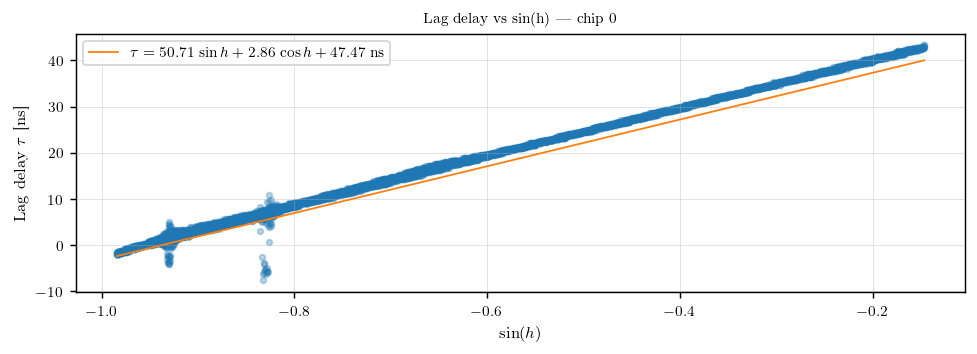

In [8]:
# --- Lag delay diagnostic plot ---
lr = lag_results[best_chip]
if lr is not None:
    sl = chip_slices[best_chip]
    sin_h = np.sin(ha_rad_arr[sl])
    tau_ns = lr.metadata["tau_ns"]
    valid = np.isfinite(tau_ns)

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
    ax.scatter(sin_h[valid], tau_ns[valid], s=SCATTER_S_FINE, color=PRIMARY_COLOR, alpha=0.3)

    # Overlay 2-component fit: tau = A*sin(h) + B*cos(h) + tau_inst
    x_fit = np.linspace(sin_h[valid].min(), sin_h[valid].max(), 100)
    A_ns = lr.metadata["A_ns_per_sinh"]
    B_ns = lr.metadata["B_ns_per_cosh"]
    intercept = lr.metadata["tau_inst_ns"]
    # For the plot vs sin(h), the cos(h) term adds scatter — show the sin(h) trend
    ax.plot(x_fit, A_ns * x_fit + intercept, lw=LW_STANDARD, color=SECONDARY_COLOR,
            label=rf"$\tau = {A_ns:.2f}\,\sin h + {B_ns:.2f}\,\cos h + {intercept:.2f}$ ns")

    ax.set_xlabel(r"$\sin(h)$")
    ax.set_ylabel(r"Lag delay $\tau$ [ns]")
    ax.set_title(f"Lag delay vs sin(h) — chip {best_chip}", fontsize=TICK_SIZE)
    ax.legend(fontsize=TICK_SIZE)
    fig.tight_layout()
    plt.show()

## 4.5 Method 4: Nonlinear least-squares fringe fit

This method fits the full fringe equation from the lab manual directly to the observed real-part visibility:

$$F(h) = A\cos\!\bigl[2\pi(Q_{\mathrm{ew}}\sin h + Q_{\mathrm{ns}}\cos h)\bigr] + B\sin\!\bigl[2\pi(Q_{\mathrm{ew}}\sin h + Q_{\mathrm{ns}}\cos h)\bigr],$$

where $Q_{\mathrm{ew}} = (b_{\mathrm{ew}}/\lambda)\cos\delta$ and $Q_{\mathrm{ns}} = (b_{\mathrm{ns}}/\lambda)\sin L\,\cos\delta$. The parameters $(A, B)$ are solved analytically at each iteration (linear), while $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$ are optimised via `scipy.optimize.least_squares`. This is the most general method — it uses all the data, fits both baselines, and makes no linearising approximations.

In [9]:
# --- Method 4: NLS fringe fit (per chip + pooled, broadband) ---
nls_results = []

for ci, sl in enumerate(chip_slices):
    ha_chip = ha_rad_arr[sl]
    corr_chip = corr_dc[sl]
    dec_chip = np.deg2rad(np.nanmean(sun_dec[sl]))

    res, _ = nls_baseline_broadband(
        ha_chip, corr_chip, dec_chip, F_SKY_HZ,
        bad_channels=BAD_CHANNELS, band_hz=band_hz,
    )
    nls_results.append(res)

    if res is not None:
        print(f"  Chip {ci}: B_EW = {res.b_ew_m:.4f} +/- {res.b_ew_err_m:.4f} m,  "
              f"B_NS = {res.b_ns_m:.4f} +/- {res.b_ns_err_m:.4f} m  ({res.n_points} ch)")

# Pooled
nls_pooled, _ = nls_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_mean, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
nls_results.append(nls_pooled)
if nls_pooled is not None:
    print(f"  Pooled: B_EW = {nls_pooled.b_ew_m:.4f} +/- {nls_pooled.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_pooled.b_ns_m:.4f} +/- {nls_pooled.b_ns_err_m:.4f} m  ({nls_pooled.n_points} ch)")

  Chip 0: B_EW = 20.2375 +/- 0.1185 m,  B_NS = -0.3415 +/- 0.1702 m  (285 ch)
  Chip 1: B_EW = 19.3684 +/- 1.6323 m,  B_NS = 10.5890 +/- 26.7675 m  (285 ch)
  Chip 2: B_EW = 19.9872 +/- 0.0981 m,  B_NS = -0.0253 +/- 0.7966 m  (285 ch)
  Pooled: B_EW = 20.0276 +/- 0.0345 m,  B_NS = -0.0625 +/- 0.0786 m  (285 ch)


## 4.6 Combined baseline estimate

We combine all valid per-chip estimates from all four methods using inverse-variance weighting with MAD-based outlier rejection, independently for $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$.

In [10]:
# --- Combined baseline ---
all_results = fft_results + ps_results + lag_results + nls_results
combined = combined_baseline(all_results)

print(f"Combined B_EW = {combined.b_ew_m:.4f} +/- {combined.b_ew_err_m:.4f} m")
print(f"Combined B_NS = {combined.b_ns_m:.4f} +/- {combined.b_ns_err_m:.4f} m")
print(f"  from {combined.n_points} estimates, "
      f"{combined.metadata.get('n_clipped_ew', 0)} clipped (EW), "
      f"{combined.metadata.get('n_clipped_ns', 0)} clipped (NS)")

# Summary table — each method list has N_chips per-chip entries + 1 pooled entry
def _fmt(val, fallback="---"):
    return f"{val:>12.4f}" if np.isfinite(val) else f"{fallback:>12}"

print("\n--- Baseline Summary ---")
print(f"{'':>25} {'B_EW [m]':>12} {'err':>8} {'B_NS [m]':>12} {'err':>8}")
print("-" * 67)
for method_label, result_list in [("FFT", fft_results),
                                   ("Phase slope", ps_results),
                                   ("Lag delay", lag_results),
                                   ("NLS fringe fit", nls_results)]:
    for idx, res in enumerate(result_list):
        if res is None:
            continue
        tag = f"chip {idx}" if idx < N_chips else "pooled"
        print(f"  {tag:>6} {method_label:<17}"
              f" {_fmt(res.b_ew_m)} {_fmt(res.b_ew_err_m, 'inf'):>8}"
              f" {_fmt(res.b_ns_m)} {_fmt(res.b_ns_err_m, 'inf'):>8}")
print("-" * 67)
print(f"  {'Combined':<24}"
      f" {_fmt(combined.b_ew_m)} {_fmt(combined.b_ew_err_m):>8}"
      f" {_fmt(combined.b_ns_m)} {_fmt(combined.b_ns_err_m):>8}")

# Store for later use
B_EW = combined.b_ew_m
B_NS = combined.b_ns_m if np.isfinite(combined.b_ns_m) else 0.0
R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)

Combined B_EW = 15.1361 +/- 0.0012 m
Combined B_NS = 1.3084 +/- 0.0251 m
  from 12 estimates, 4 clipped (EW), 10 clipped (NS)

--- Baseline Summary ---
                              B_EW [m]      err     B_NS [m]      err
-------------------------------------------------------------------
  chip 0 FFT                    15.6414       0.0050       0.0000          inf
  chip 1 FFT                    15.2106       0.0073       0.0000          inf
  chip 2 FFT                    14.9470       0.0015       0.0000          inf
  pooled FFT                    15.5439       0.0026       0.0000          inf
  chip 0 Phase slope            15.4627       0.0075       0.0000          inf
  chip 1 Phase slope            14.1311       0.1684       0.0000          inf
  chip 2 Phase slope            14.8267       0.0198       0.0000          inf
  pooled Phase slope            14.4993       0.0102       0.0000          inf
  chip 0 Lag delay              15.2038       0.0389       1.3950       0.0711

# Part V: Fringe Model Comparison

With the baseline determined, we construct a full forward model and compare against the data.

## 5.1 Elevation-dependent amplitude envelope

The raw model assumes constant amplitude, but the observed fringe amplitude drops toward the horizon due to:

1. **Atmospheric opacity** — the optical depth increases as $\sec(z) = 1/\sin(\mathrm{alt})$ at low elevation, attenuating the signal as $e^{-\tau_0/\sin(\mathrm{alt})}$.
2. **Antenna gain variation** — primary beam efficiency, ground spillover, and ohmic losses change with elevation.

We model this empirically by multiplying the geometric fringe model by the observed amplitude envelope (smoothed), which captures the combined elevation-dependent gain without needing to decompose the individual contributions.

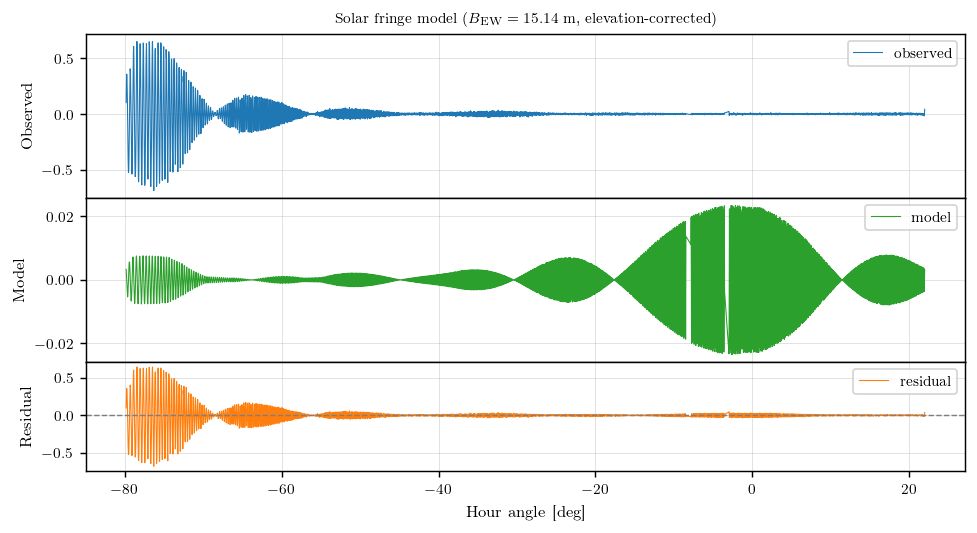

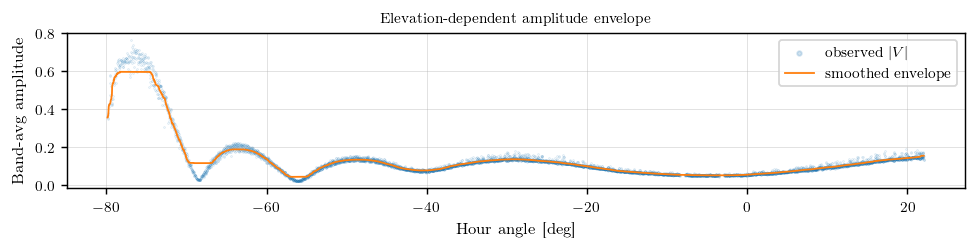

In [11]:
# --- Band-averaged observed fringes ---
corr_band = corr_dc[:, band_mask]
obs_real = np.nanmean(corr_band.real, axis=1)
obs_amp  = np.nanmean(np.abs(corr_band), axis=1)

# --- Observed amplitude envelope (smoothed) ---
# This captures the elevation-dependent gain: atmosphere + beam + system temperature.
# We use a running median to extract the slow envelope without fringe contamination.
from scipy.ndimage import median_filter
env_smooth_size = 301  # ~5 min at 2.6 s cadence
obs_envelope = median_filter(obs_amp, size=env_smooth_size, mode="nearest")

# --- Geometric fringe model with fitted baseline ---
params_fit = FringeModelParams(
    b_ew=B_EW,
    b_ns=B_NS,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,       # unit amplitude; envelope applied separately
    phase_offset=0.0,
)
disk_fit = SolarDiskParams(angular_radius_rad=R_nominal)
model_unit = solar_visibility(ha_rad_arr, params_fit, disk_fit)

# --- Apply observed amplitude envelope to the model ---
# This ensures the model has the correct elevation-dependent gain taper.
# We then fit only the overall scale and phase offset.
model_enveloped = model_unit * obs_envelope

from scipy.optimize import minimize_scalar

def _phase_residual(phi0):
    rotated = model_enveloped * np.exp(1j * phi0)
    return np.nansum((obs_real - rotated.real) ** 2)

phi_opt = minimize_scalar(_phase_residual, bounds=(-np.pi, np.pi), method="bounded")
model_aligned = model_enveloped * np.exp(1j * phi_opt.x)

scale = np.nansum(obs_real * model_aligned.real) / np.nansum(model_aligned.real ** 2)
model_scaled = (scale * model_aligned).real
residual = obs_real - model_scaled

fig, axes = plot_fringe_model_comparison(
    ha_deg_arr, obs_real, model_scaled, residual,
    title=f"Solar fringe model ($B_{{\\rm EW}} = {B_EW:.2f}$ m, elevation-corrected)",
)
plt.show()

# --- Also show the amplitude envelope ---
fig2, ax2 = plt.subplots(figsize=(TEXTWIDTH_IN, 2.0))
ax2.scatter(ha_deg_arr, obs_amp, s=0.1, color=PRIMARY_COLOR, alpha=0.2,
            rasterized=True, label="observed $|V|$")
ax2.plot(ha_deg_arr, obs_envelope, lw=LW_STANDARD, color=SECONDARY_COLOR,
         label="smoothed envelope")
ax2.set_xlabel("Hour angle [deg]")
ax2.set_ylabel("Band-avg amplitude")
ax2.set_title("Elevation-dependent amplitude envelope", fontsize=TICK_SIZE)
ax2.legend(fontsize=TICK_SIZE, markerscale=8)
fig2.tight_layout()
plt.show()